In [1]:
import sys
sys.path.append("../2_train_models")

from file_configs import MergedFilesConfig
from data_loading import extract_peaks, extract_observed_profiles

import torch
import h5py
import numpy as np
import pandas as pd
import os
import math
from collections import defaultdict
import gzip


    
def load_motif_cwms(modisco_results_path, include = None):
    new_f = h5py.File(modisco_results_path, "r")
    
    cwm_dict = defaultdict(lambda: dict())
    for patterns_group_name in ['pos_patterns', 'neg_patterns']:
        if (include is not None) and (patterns_group_name not in include.keys()):
            continue
        
        # if the results include pos/neg patterns...
        if patterns_group_name in new_f.keys():
            new_patterns_grp = new_f[patterns_group_name]
            
            # if there are any patterns for this metacluster...
            if len(new_patterns_grp.keys()) > 0:
                pattern_names = list(new_patterns_grp.keys())
                pattern_names = sorted(pattern_names, key = lambda name : int(name.split("_")[1]))
                
                # for each hit...
                
                for pattern in pattern_names:
                    if include is not None:
                        if int(pattern.replace("pattern_", "")) not in include[patterns_group_name]:
                            continue
                    
                    pattern_grp = new_patterns_grp[pattern]
                    cwm_dict[patterns_group_name][pattern] = pattern_grp["contrib_scores"][:]
    new_f.close()
    
    return cwm_dict


def load_coords(peak_bed, in_window=2114):
    if peak_bed.endswith(".gz"):
        with gzip.open(peak_bed) as f:
            lines = [line.decode().split() for line in f]
    else:
        with open(peak_bed) as f:
            lines = [line.split() for line in f]

    coords = []
    for line in lines:
        chrom, peak_start, peak_end = line[0], int(line[1]), int(line[2])
        mid = (peak_start + peak_end) // 2
        window_start = mid - in_window // 2
        window_end = mid + in_window // 2
        coords.append((chrom, window_start, window_end))
    return coords


def trim_motif_by_thresh(pfm, trim_threshold=0.2, pad=2):
    trim_thresh = np.max(pfm) * trim_threshold
    pass_inds = np.where(pfm >= trim_thresh)[0]

    start = max(np.min(pass_inds) - pad, 0)
    end = min(np.max(pass_inds) + pad + 1, len(pfm) + 1)
    
    return pfm[start:end]


class MotifScanner(torch.nn.Module):

    def __init__(self, motifs, bin_size=0.1, eps=1e-4):
        super().__init__()

        # trim and height-normalize each motif
        motifs = [trim_motif_by_thresh(motif) for motif in motifs]
        motifs = [motif / motif.sum() for motif in motifs]
        
        n = len(motifs)
        lengths = np.array([len(motif) for motif in motifs])
        max_len = max(lengths)
        cwms = torch.zeros((n, 4, max_len), dtype=torch.float32)

        self.bin_size = bin_size

        self.motif_names = []
        self._score_to_pval = []
        self._smallest = []

        for i, cwm in enumerate(motifs):
            # 0-min is needed because of log
            # (some motifs have a negative base or two)
            # and 1.5ing is there cause it helps stuff look better
            cwm = torch.from_numpy(np.maximum(cwm, 0) ** 1.5).T
            cwms[i, :, :cwm.shape[-1]] = torch.exp(torch.log(cwm + eps) - np.log(0.25))

        self.cwms = cwms
        self.lengths = lengths
        self.max_len = max_len
        self.conv = torch.nn.Conv1d(4, n, kernel_size=max_len, bias=False)
        self.conv.weight = torch.nn.Parameter(cwms)

    @torch.no_grad()
    def forward(self, X):
        return self.conv(X)

    @torch.no_grad()
    def predict(self, X, batch_size=64):
        scores = []
        for start in range(0, len(X)+batch_size, batch_size):
            X_ = X[start:start+batch_size].to(self.conv.weight.device)
            scores.append(self(X_).cpu())

        return torch.cat(scores).numpy().squeeze()


def calc_scores(seqs, scanner):
    with torch.no_grad():
        scores_seq = np.abs(scanner.predict(torch.tensor(seqs).float()))
    return scores_seq


def seq_scores_to_hits(scores, seq_threshs, motif_names):
    hits = []
    for motif_i in range(scores.shape[-2]):
        motif_scores = np.log1p(scores[..., motif_i, :])
        where_high = (motif_scores > seq_threshs[motif_names[motif_i]]).nonzero()
        #thresh = np.quantile(motif_scores.flatten(), seq_threshs[motif_names[motif_i]])
        #where_high = (motif_scores > thresh).nonzero()
        hits.append(np.array(where_high))
    return hits


def attr_scores_to_hits(scores, attr_threshs, motif_names):
    hits = []
    for motif_i in range(scores.shape[-2]):
        motif_scores = scores[..., motif_i, :]
        quant_cutoff = np.quantile(motif_scores, attr_threshs[motif_names[motif_i]])
        where_high = (motif_scores > quant_cutoff).nonzero()
        hits.append(np.array(where_high))
    return hits


def merge_seq_and_attr_hits(seq_hits_fwd, seq_hits_rev, attr_hits_fwd, attr_hits_rev, num_motifs):
    hits_fwd = []
    hits_rev = []
    for motif_i in range(num_motifs):
        seq_fwd_hits_set = { tuple(hit) for hit in seq_hits_fwd[motif_i].T }
        attr_fwd_hits_set = { tuple(hit) for hit in attr_hits_fwd[motif_i].T }

        hits_fwd_combo = seq_fwd_hits_set.intersection(attr_fwd_hits_set)
        hits_fwd.append(np.array(sorted(list(hits_fwd_combo))).T)

        seq_rev_hits_set = { tuple(hit) for hit in seq_hits_rev[motif_i].T }
        attr_rev_hits_set = { tuple(hit) for hit in attr_hits_rev[motif_i].T }

        hits_rev_combo = seq_rev_hits_set.intersection(attr_rev_hits_set)
        hits_rev.append(np.array(sorted(list(hits_rev_combo))).T)
        
    return hits_fwd, hits_rev
    
    
def get_overlap_group_labels(hits, motif_pad = 2):
    group_label = 0
    group_labels = [0]
    for hit_i in range(len(hits) - 1):
        if hits[hit_i + 1][0] + motif_pad > hits[hit_i][1] - motif_pad:
            group_label += 1
        group_labels.append(group_label)
        
    return group_labels

    
def resolve_overlaps_both_strands(hits_fwd, hits_rev, attr_scores_fwd, attr_scores_rev, motif_lengths, num_loci):
    
    all_resolved_hits = defaultdict(lambda : [])
    for peak_index in range(num_loci):
        all_hits_in_peak = []

        motif_hits_in_peak = {}
        for motif_i in range(len(motif_lengths)):
            motif_len = motif_lengths[motif_i]
            
            motif_hits_fwd = hits_fwd[motif_i][1][hits_fwd[motif_i][0] == peak_index]
            all_hits_in_peak.extend([(start, start + motif_len, motif_i, "+") for start in motif_hits_fwd])
            
            motif_hits_rev = hits_rev[motif_i][1][hits_rev[motif_i][0] == peak_index]
            all_hits_in_peak.extend([(start, start + motif_len, motif_i, "-") for start in motif_hits_rev])

        all_hits_in_peak = sorted(all_hits_in_peak)
        overlap_group_labels = get_overlap_group_labels(all_hits_in_peak)
        
        all_hits_in_peak = np.array(all_hits_in_peak)
        num_hits = len(all_hits_in_peak)
        
        if num_hits == 0:
            continue
        
        resolved_hits = []
        for overlap_group in range(overlap_group_labels[-1] + 1):
            overlapping_hits_idxs = [i for i in range(num_hits) if overlap_group_labels[i] == overlap_group]
            overlapping_hits = all_hits_in_peak[overlapping_hits_idxs]
            
            if len(overlapping_hits) == 0:
                print("Oh no")
                continue  # shouldn't happen
            
            if len(overlapping_hits) == 1:
                resolved_hits.append(overlapping_hits[0])
            else:
                overlapping_attr_scores = []
                for overlapping_hit in overlapping_hits:
                    start, _ , motif_i, strand = overlapping_hit
                    start = int(start)
                    motif_i = int(motif_i)
                    motif_len = motif_lengths[motif_i]
                    motif_len_adj = max(1, motif_len - 5)
                    
                    if strand == "+":
                        overlapping_attr_scores.append(attr_scores_fwd[peak_index, motif_i, start] * motif_len_adj)
                    else:
                        overlapping_attr_scores.append(attr_scores_rev[peak_index, motif_i, start] * motif_len_adj)

                resolved_hits.append(overlapping_hits[np.argmax(overlapping_attr_scores)])
    
        for start, _, motif_i, strand in resolved_hits:
            motif_i = int(motif_i)
            all_resolved_hits[motif_i].append((int(peak_index), int(start), strand))

    all_resolved_hits = [np.array(all_resolved_hits[i]).T for i in range(len(motif_lengths))]
    return all_resolved_hits


def hits_to_bed_intervals(hits, coords, motif_lengths, motif_names):
    bed_lines = []
    for motif_i, motif_hits in enumerate(hits):
        motif_len = motif_lengths[motif_i]
        for hit_peak_index, hit_position, strand in motif_hits.T:
            chrom, peak_start, _ = coords[int(hit_peak_index)][:3]
            hit_start = int(peak_start) + int(hit_position)
            hit_end = int(hit_start) + motif_len
            
            line = [chrom, hit_start + 2, hit_end - 2]
            line += [motif_names[motif_i], hit_peak_index, strand, motif_i]
            bed_lines.append(tuple(line))

    bed_lines = sorted(list(set(bed_lines)))
    return bed_lines

In [2]:
cell_type = "K562"
model_type = "strand_merged_umap"
data_type = "procap"

in_window = 2114
out_window = 1000


config = MergedFilesConfig(cell_type, model_type, data_type)

proj_dir = config.proj_dir
modisco_dir = proj_dir + "/".join(["modisco_out", data_type, cell_type, model_type, "merged"]) + "/"

# mostly using the profile modisco CWMs because they came out cleaner
prof_modisco_results = modisco_dir + "profile_modisco_results.hd5"
counts_modisco_results = modisco_dir + "counts_modisco_results.hd5"

# output of this script will be:
hits_filepath = proj_dir + "motifs_out/" + data_type + "/" + cell_type + "/" + model_type + "/merged/profile_hits.bed"
counts_hits_filepath = proj_dir + "motifs_out/" + data_type + "/" + cell_type + "/" + model_type + "/merged/counts_hits.bed"


# select the modisco patterns you want to get hits for (0-indexed)
# don't include nonspecific GC-rich hits or things that aren't really motifs
# also give them names (to be used in output bed file)

counts_motif_names = []
counts_include = []
if cell_type == "K562":
    prof_motif_names = ["BRE/SP", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
                   "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "TCT", "TATATA"]
    prof_include = list(range(10)) + [13,15,19,21,23]
if cell_type == "A673":
    prof_motif_names = ["BRE/SP", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
                   "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "TCT",
                   "ATF4"]
    prof_include = [3,0,5,4,11,7,6,17,13,12,16,20,22,19,15]
    counts_motif_names = ["EWS-FLI"]
    counts_include = [10]
if cell_type == "CACO2":
    prof_motif_names = ["BRE/SP", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
           "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "TCT", "TATATA",
           "ATF4", "HNF1A/B", "TEAD", "FOX", "HNF4A/G"]
    prof_include = [1,0,5,3,6,4,7,14,10,12,11,15,17,25,22,19,13,8,31,16]
    counts_motif_names = ["GRHL1", "CEBP"]
    counts_include = [27, 31]
if cell_type == "CALU3":
    prof_motif_names = ["BRE/SP", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
           "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "HNF1A/B"]
    prof_include = [1,0,3,4,9,6,13,14,10,5,27,18,17,15]
    counts_motif_names = ["IRF/STAT", "RFX"]
    counts_include = [12,15]
if cell_type == "HUVEC":
    prof_motif_names = ["BRE/SP", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
                   "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "TATATA"]
    prof_include = [2,0,1,3,8,6,12,16,13,4,15,23,18,20]
if cell_type == "MCF10A":
    prof_motif_names = ["BRE/SP", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
                   "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "TCT",
                   "ATF4", "CEBP", "RFX"]
    prof_include = [2,0,6,4,8,5,15,16,14,1,11,18,19,21,10,27,30]
    counts_motif_names = ["IRF/STAT"]
    counts_include = [28]


### Load in modisco motif CWMs, sequences to find hits in, etc.
# this will sort them correctly with respect to the ordering in the include list

prof_cwms = load_motif_cwms(prof_modisco_results, {"pos_patterns" : prof_include})
prof_cwms = [prof_cwms["pos_patterns"]["pattern_" + str(motif_i)] for motif_i in prof_include]

counts_cwms = load_motif_cwms(counts_modisco_results, {"pos_patterns" : counts_include})
counts_cwms = [counts_cwms["pos_patterns"]["pattern_" + str(motif_i)] for motif_i in counts_include]

if cell_type == "A673":
    # the only instance where a negative motif pattern is needed
    counts_neg_cwms = load_motif_cwms(counts_modisco_results, {"neg_patterns" : [1]})
    counts_neg_cwms = [counts_neg_cwms["neg_patterns"]["pattern_1"]]
    counts_cwms += counts_neg_cwms

    counts_motif_names += ["SNAI"]

motif_names = prof_motif_names + counts_motif_names
cwms = prof_cwms + counts_cwms

assert len(motif_names) == len(cwms), (cell_type, len(motif_names), len(cwms))


# test these out and fiddle with them in the notebook

seq_threshs = {"BRE/SP" : 0.72,
            "CA-Inr" : 0.87,
            "ETS" : 0.63,
            "NFY" : 0.81,
            "NRF1" : 0.56,
            "ATF1" : 0.66,
            "TATA" : 0.81,
            "THAP11" : 0.48,
            "YY1" : 0.55,
            "AP1" : 0.72,
            "TA-Inr" : 1.02,
            "CTCF" : 0.63,
            "ZBTB33" : 0.69,
            "TCT" : 0.61,
            "TATATA" : 0.75,
            "ATF4" : 0.5,
            "HNF1A/B" : 0.5,
            "TEAD" : 0.5,
            "FOX" : 0.5,
            "HNF4A/G" : 0.5,
            "CEBP" : 0.5,
            "RFX" : 0.5}

# seq_threshs = {"BRE/SP" : 0.9964554811,
#                 "CA-Inr" : 0.9348683587,
#                 "ETS" : 0.9993171805,
#                 "NFY" : 0.9988540347,
#                 "NRF1" : 0.9990283846,
#                 "ATF1" : 0.9994912639,
#                 "TATA" : 0.9990056365,
#                 "THAP11" : 0.999951180147,
#                 "YY1" : 0.9999785218,
#                 "AP1" : 0.9995172729,
#                 "TA-Inr" : 0.9622725538,
#                 "CTCF" : 0.9999838521,
#                 "ZBTB33" : 0.9999358318,
#                 "TCT" : 0.9944938606,
#                 "TATATA" : 0.9976544522,
#                 "ATF4" : 0.9995,
#                 "HNF1A/B" : 0.999995,
#                 "TEAD" : 0.999,
#                 "FOX" : 0.9999,
#                 "HNF4A/G" : 0.9995,
#                 "CEBP" : 0.999,
#                 "RFX" : 0.9999,
#                 "EWS-FLI" : 0.9999,
#                 "IRF/STAT" : 0.9998,
#                 "SNAI" : 0.9999,
#                 "GRHL1" : 0.99999}

attr_threshs = {"BRE/SP" : 0.975,
                "CA-Inr" : 0.999,
                "ETS" : 0.975,
                "NFY" : 0.975,
                "NRF1" : 0.975,
                "ATF1" : 0.999,
                "TATA" : 0.975,
                "THAP11" : 0.975,
                "YY1" : 0.975,
                "AP1" : 0.975,
                "TA-Inr" : 0.999,
                "CTCF" : 0.99,
                "ZBTB33" : 0.98,
                "TCT" : 0.9995,
                "TATATA" : 0.975,
                "ATF4" : 0.975,
                "HNF1A/B" : 0.975,
                "TEAD" : 0.975,
                "FOX" : 0.975,
                "HNF4A/G" : 0.975,
                "CEBP" : 0.975,
                "RFX" : 0.975,
                "EWS-FLI" : 0.9,
                "IRF/STAT" : 0.975,
                "SNAI" : 0.985,
                "GRHL1" : 0.975}




# load sequences you want to call hits in

onehot_seqs, _ = extract_peaks(config.genome_path,
                                config.chrom_sizes,
                                config.plus_bw_path,
                                config.minus_bw_path,
                                config.all_peak_path,
                                in_window=in_window,
                                out_window=out_window,
                                max_jitter=0,
                                verbose=True)
num_loci = len(onehot_seqs)

# load genomic coordinates for all the sequences you want to call hits in
# (used when the hits are written into a bed file)
coords = load_coords(config.all_peak_path)

Loading genome sequence from /mnt/lab_data2/kcochran/procapnet/genomes/hg38.withrDNA.fasta


Reading FASTA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:10<00:00,  2.38it/s]
Loading Peaks: 30534it [00:38, 799.15it/s]


== In Extract Peaks ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks.bed.gz
Sequence length (with jitter): 2114
Profile length (with jitter): 1000
Max jitter applied: 0
Num. Examples: 30534
Mask loaded? False


In [4]:
# Go

scores_path = config.profile_scores_path
#scores_path = config.counts_scores_path
cwms_list = cwms
normalize_scores = True

# load attributions for the sequences you want to call hits in
scores_raw = np.load(scores_path)
# results looked a little better when the scores were normalized per-example
if normalize_scores:
    scores = scores_raw / scores_raw.sum(axis=(-1,-2), keepdims=True)
    del scores_raw
else:
    scores = scores_raw

# Want to look for hits that have high scores in both
# raw sequence match AND attribution match, so we will score both

# first, load CWMs from modisco results into motif-scanning class
scanner_fwd = MotifScanner(cwms_list)
scanner_rev = MotifScanner([cwm[::-1, ::-1] for cwm in cwms_list])
motif_lengths = scanner_fwd.lengths

In [5]:
# score all positions by similarity in sequence to motif
# (repeat for motif reverse complemented)
seq_scores_fwd = calc_scores(onehot_seqs, scanner_fwd)
seq_scores_rev = calc_scores(onehot_seqs, scanner_rev)

# apply thresholds to turn scores into binary hits
seq_hits_fwd = seq_scores_to_hits(seq_scores_fwd, seq_threshs, motif_names)
seq_hits_rev = seq_scores_to_hits(seq_scores_rev, seq_threshs, motif_names)
del seq_scores_fwd, seq_scores_rev

In [6]:
# now do the same thing but with the attributions / contrib. scores
attr_scores_fwd = calc_scores(scores, scanner_fwd)
attr_scores_rev = calc_scores(scores, scanner_rev)

attr_hits_fwd = attr_scores_to_hits(attr_scores_fwd, attr_threshs, motif_names)
attr_hits_rev = attr_scores_to_hits(attr_scores_rev, attr_threshs, motif_names)

In [7]:
# Merge matches across both the sequence and the attribution scans
hits_fwd, hits_rev = merge_seq_and_attr_hits(seq_hits_fwd, seq_hits_rev,
                                             attr_hits_fwd, attr_hits_rev,
                                             len(motif_lengths))

In [8]:
# In cases where multiple hits are on top of each other, figure out best one
resolved_hits = resolve_overlaps_both_strands(hits_fwd, hits_rev,
                                              attr_scores_fwd, attr_scores_rev,
                                              motif_lengths, len(onehot_seqs))

In [20]:
for arr1, arr2 in zip(seq_hits_fwd, seq_hits_rev):
    print(arr1.shape[1] + arr2.shape[1])


451541
8304122
86478
145277
124318
64902
126943
6224
2586
61128
4812930
2109
8202
701749
299303


In [15]:
for arr1 in hits_fwd:
    print(arr1.shape[1])

47125
28399
11987
9851
18131
2963
3712
1162
765
5891
12880
435
1274
219
7322


In [21]:
for arr1, arr2 in zip(hits_fwd, hits_rev):
    print(arr1.shape[1] + arr2.shape[1])

92744
56605
23814
19495
36430
5789
7436
2318
1398
11630
25569
889
2536
423
14659


In [17]:
for arr1, arr2, arr3, arr4 in zip(seq_hits_fwd, seq_hits_rev, hits_fwd, hits_rev):
    unfiltered_n = arr1.shape[1] + arr2.shape[1]
    filtered_n = arr3.shape[1] + arr4.shape[1]
    print(unfiltered_n, filtered_n, filtered_n/unfiltered_n)

451541 92744 0.20539441601094918
8304122 56605 0.006816494266341463
86478 23814 0.2753763963088878
145277 19495 0.13419192301603144
124318 36430 0.29303881980083335
64902 5789 0.08919601861267758
126943 7436 0.05857747177867232
6224 2318 0.3724293059125964
2586 1398 0.5406032482598608
61128 11630 0.19025651092788903
4812930 25569 0.005312564279970828
2109 889 0.4215267899478426
8202 2536 0.3091928797854182
701749 423 0.0006027796263336321
299303 14659 0.048977123516971095


In [22]:
for arr in resolved_hits:
    print(arr.shape[1])

66893
31341
18431
17214
14171
3321
3502
2171
1243
6253
7303
654
1182
120
4386


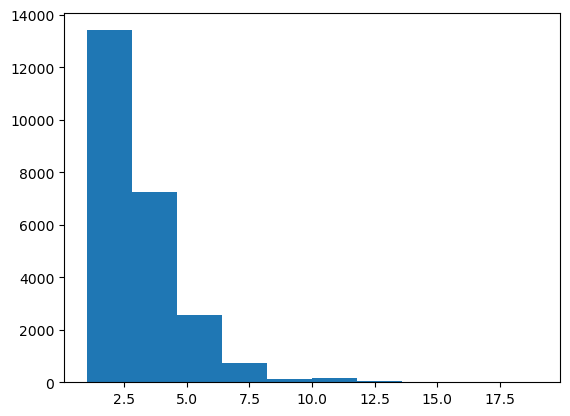

In [19]:
import matplotlib.pyplot as plt
from collections import defaultdict

counter = defaultdict(lambda : 0)
for num in resolved_hits[0][0]:
    counter[int(num)] += 1

plt.hist(counter.values())
plt.show()